In [2]:
from IPython.display import display, clear_output
import numpy as np
import matplotlib.pyplot as plt

In [3]:
a = 1
l = 3

n = 101

In [4]:
T = l/a
h = 2*l/n
t = h/5*a
eps = 3*h
sigma = h

time = 0

x = np.linspace(-l, l, n)
y = np.linspace(-l, l, n)
X, Y = np.meshgrid(x, y)
r = np.sqrt(X**2 + Y**2)

mask = (np.abs(X) <= eps) & (np.abs(Y) <= eps)

U01 = np.zeros((n,n))
U01[mask] = (1 / eps**2) * (1 + np.cos(np.pi * X[mask]/eps))/2 * (1 + np.cos(np.pi * Y[mask]/eps))/2

U02 = np.zeros((n,n))
U02 = (1 / (2 * np.pi * sigma**2)) * np.exp(-((X**2 + Y**2)/(2 * sigma**2)))

U03 = np.zeros((n,n))
U03[mask] = (4 / (np.pi * eps**2)) * (1 - (X[mask]**2 + Y[mask]**2)/(eps ** 2))

Ut = np.zeros((n,n))

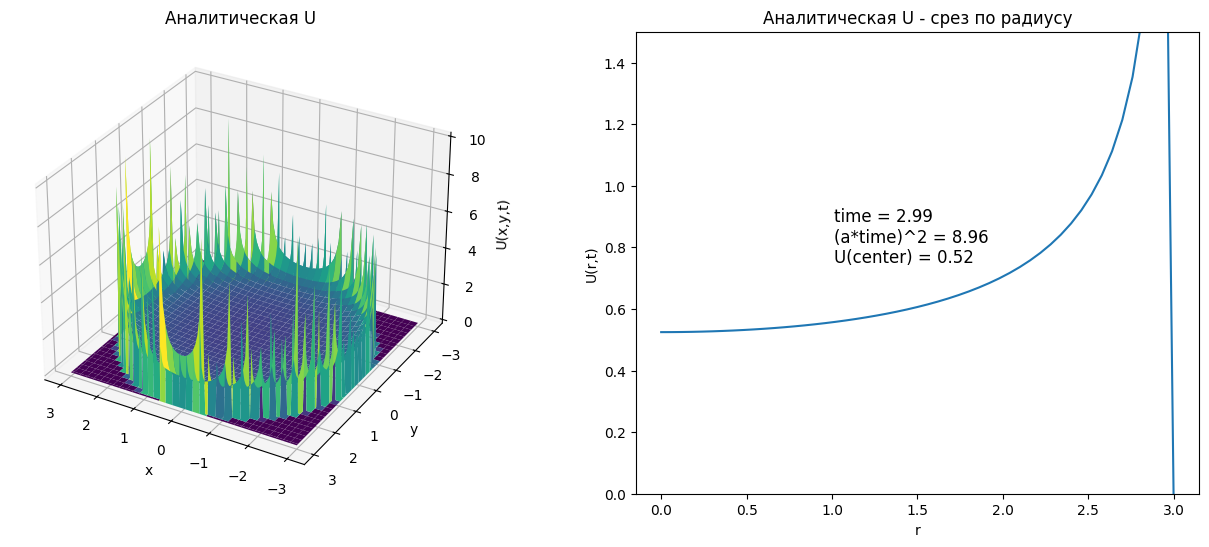

In [5]:
U_analytical = np.zeros((n,n))
time = 0


plt.ion()
fig = plt.figure(figsize=(16,6))
ax = fig.add_subplot(121, projection='3d')
surf = ax.plot_surface(X, Y, U_analytical,
                    cmap='viridis')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('U(x,y,t)')
ax.set_zlim(0, 10)
ax.set_title('Аналитическая U')
ax.view_init(elev=30, azim=120)

ax1 = fig.add_subplot(122)
ax1.set_ylim(0,1.5)
ax1.set_xlabel('r')
ax1.set_ylabel('U(r,t)')
ax1.set_title('Аналитическая U - срез по радиусу')

ax2 = fig.add_subplot(1,3,3)
ax2.axis('off')

N = n//2
surf1, = ax1.plot(r[N,N:], U_analytical[N,N:])


display(fig)

while time < T:
    mask = r < a * time
    U_analytical[mask] = (1 /2*np.pi*a) * (1 / np.sqrt((a * time)**2 - X[mask]**2 - Y[mask]**2))
    U_analytical[U_analytical > 10] = 10
    
    surf.remove()
    surf = ax.plot_surface(X, Y, U_analytical, cmap='viridis')

    surf1.set_ydata(U_analytical[N, N:])

    ax2.clear()
    ax2.axis('off')
    ax2.text(0, 0.5, f"time = {time:.2f}\n(a*time)^2 = {(a*time)**2:.2f}\nU(center) = {U_analytical[n//2,n//2]:.2f}", 
            fontsize=12)
    clear_output(wait=True)
    display(fig)
    plt.pause(0.05)
    
    time += t
plt.ioff()

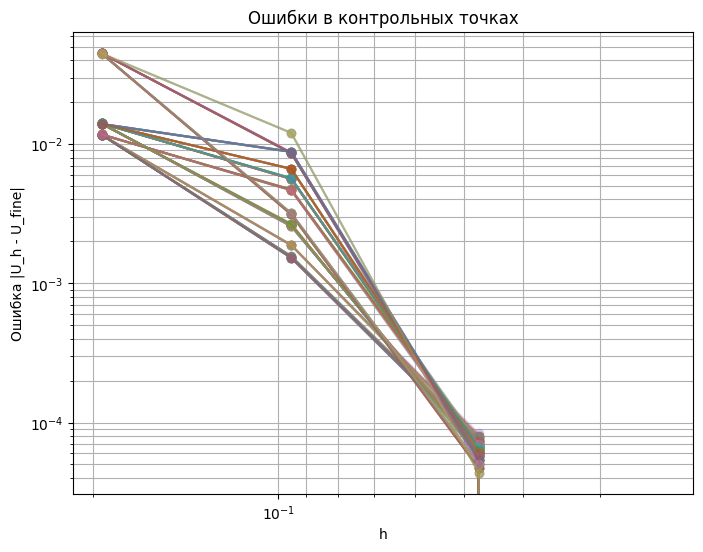

Средний порядок схемы по всем точкам: 3.98
Минимальный порядок: 3.50, Максимальный: 4.92


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Сохраним решения для разных n
n_values = [32, 64, 128, 256]
solutions = {}
x_coords = {}
y_coords = {}

sigma = 0.1  # ширина гаусса

for n in n_values:
    h = 2*l/(n-1)
    t_step = h/(5*a)
    x = np.linspace(-l, l, n)
    y = np.linspace(-l, l, n)
    X, Y = np.meshgrid(x, y)
    x_coords[n] = x
    y_coords[n] = y
    
    # начальное условие
    U0 = (1 / (2*np.pi*sigma**2)) * np.exp(-(X**2+Y**2)/(2*sigma**2))
    U = np.zeros((n,n,3))
    U[:,:,1] = U0
    U[1:-1,1:-1,0] = U[1:-1,1:-1,1] + (((a*t_step)**2)/(2*h**2))*(U[2:,1:-1,1]+U[:-2,1:-1,1]+U[1:-1,2:,1]+U[1:-1,:-2,1]-4*U[1:-1,1:-1,1])

    # шаг по времени до T
    time = 0
    while time < T:
        U[:,:,2] = U[:,:,1]
        U[:,:,1] = U[:,:,0]
        U[1:-1,1:-1,0] = 2*U[1:-1,1:-1,1] - U[1:-1,1:-1,2] + (((a*t_step)/h)**2)*(U[2:,1:-1,1]+U[:-2,1:-1,1]+U[1:-1,2:,1]+U[1:-1,:-2,1]-4*U[1:-1,1:-1,1])
        time += t_step
    
    solutions[n] = U[:,:,0]

# Формируем сетку контрольных точек вокруг центра
grid_points = np.arange(-0.3, 0.35, 0.05)  # от -0.3 до 0.3 с шагом 0.05
points = [(x,y) for x in grid_points for y in grid_points]

errors = {pt: [] for pt in points}
hs = []

n_fine = n_values[-1]
U_fine = solutions[n_fine]
x_fine = x_coords[n_fine]
y_fine = y_coords[n_fine]

for n in n_values:
    h = 2*l/(n-1)
    hs.append(h)
    U = solutions[n]
    X = x_coords[n]
    Y = y_coords[n]
    
    for pt in points:
        i = np.argmin(np.abs(X - pt[0]))
        j = np.argmin(np.abs(Y - pt[1]))
        i_fine = np.argmin(np.abs(x_fine - pt[0]))
        j_fine = np.argmin(np.abs(y_fine - pt[1]))
        err = np.abs(U[j,i] - U_fine[j_fine,i_fine])
        errors[pt].append(err)

# Лог-лог график ошибки для всех точек
plt.figure(figsize=(8,6))
for pt in points:
    plt.loglog(hs, errors[pt], 'o-', alpha=0.3)
plt.gca().invert_xaxis()
plt.xlabel('h')
plt.ylabel('Ошибка |U_h - U_fine|')
plt.grid(True, which='both')
plt.title('Ошибки в контрольных точках')
plt.show()

# Средний порядок по всем точкам
all_orders = []
for pt in points:
    errs = np.array(errors[pt])
    p = np.polyfit(np.log(hs[:-1]), np.log(errs[:-1]), 1)[0]
    all_orders.append(p)

print(f"Средний порядок схемы по всем точкам: {np.mean(all_orders):.2f}")
print(f"Минимальный порядок: {np.min(all_orders):.2f}, Максимальный: {np.max(all_orders):.2f}")